In [1]:
import pandas as pd
import anndata as ad
import os

from utils import *
from matplotlib_venn import venn3, venn2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from adjustText import adjust_text
from gtfparse import read_gtf
import numpy as np
from sklearn.model_selection import train_test_split, GroupShuffleSplit 
import xgboost as xgb
from sklearn.model_selection import LeaveOneOut, RepeatedKFold, RepeatedStratifiedKFold, StratifiedGroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import mannwhitneyu, spearmanr, pearsonr
from statannotations import Annotator
import matplotlib
# from lightgbm import LGBMClassifier
from sklearn.dummy import DummyClassifier
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
from joblib import Parallel, delayed
from sklearn.feature_selection import VarianceThreshold 
import warnings
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import balanced_accuracy_score
# from fgclustering import FgClustering
from sklearn.metrics import roc_curve, precision_recall_curve, auc

import seaborn as sns
# import decoupler as dc

from first_part import *
from utils import *


/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packag

In [2]:
adata_tr = ad.read_h5ad("/Volumes/U32 Shadow/data/ATAC-seq/PPMI/PPMI_RNAseq_IR3_Analysis/adata_transcript.h5ad")
adata_tr.obs.groupby(['COHORT_DEFINITION', "subgroup"])['PATNO'].nunique()
condition = "subgroup"
method = 'pydeseq2_sex_adjusted_no_refit_bulk_rna'
adata_tr.obs.reset_index(drop=True, inplace=True)
adata_pd = adata_tr[adata_tr.obs['COHORT_DEFINITION'] =="Parkinson's Disease", :]
# print(adata_pd)
adata_pd.obs.reset_index(drop=True, inplace=True)
# adata_pd = adata_pd[adata_pd.obs['ENRLLRRK2'] + adata_pd.obs['ENRLGBA'] !=2, :]
# adata_pd.obs[condition] = "OTHER"
adata_pd.obs["celltype"] = "Bulk"
adata_pd.obs["brain_region"] = "blood"
adata_pd.obs["PatientID"] = adata_pd.obs["PATNO"].tolist()
adata_pd = adata_pd[adata_pd.obs["subgroup"].isin(["GBA1","LRRK2","SPOR"])]
# adata_pd.obs["subgroup"] = adata_pd.obs["subgroup"].replace({"GBA":"GBA1","Sporadic PD":"SPOR"})
adata_pd.obs["group"] = adata_pd.obs[condition].values
adata_pd.obs["condition"] = adata_pd.obs[condition].values
adata_pd.var["peakid"] = adata_pd.var_names
adata_pd
adata_pd.obs.groupby(['COHORT_DEFINITION', "subgroup"])['PATNO'].nunique()


/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packages/pandas/core/frame.py:6479: ImplicitModificationWarning: Trying to modify index of attribute `.obs` of view, initializing view as actual.
  new_obj.index = new_index
/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/var/folders/yn/qvpxfrdd5870gxhq9hf9jvc40000gq/T/ipykernel_17553/3938477560.py:16: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_pd.obs["group"] = adata_pd.obs[condition].values


COHORT_DEFINITION    subgroup
Parkinson's Disease  GBA1         44
                     LRRK2       121
                     SPOR        207
Name: PATNO, dtype: int64

In [3]:
path_g="/Volumes/U32 Shadow/data/ATAC-seq/PPMI/Subject_Demographics/Genetic_Status/iu_genetic_consensus_20231220_20Nov2024.csv"
genetic = pd.read_csv(path_g)
genetic["PATNO"] = genetic["PATNO"].astype(str)
genetic = genetic[genetic.PATNO.isin(adata_pd.obs.PATNO.unique())]
genetic.columns = [it + "_mutation" if it != "PATNO" else it for it in genetic.columns ]
genetic
adata_pd.obs = adata_pd.obs.merge(genetic[["PATNO","LRRK2_mutation",
                            "GBA_mutation","VPS35_mutation","SNCA_mutation",
                            "PRKN_mutation","PARK7_mutation","PINK1_mutation"]], on="PATNO", how="left")


In [4]:
## no treatment
tokeep = adata_pd.obs.sort_values("EVENT_ID").index#.drop_duplicates("PATNO", keep="first").index
adata_pd = adata_pd[tokeep]
adata_pd

View of AnnData object with n_obs × n_vars = 1077 × 204621
    obs: 'study', 'PATNO', 'EVENT_ID', 'sampleID', 'seqID', 'assay', 'level', 'SITE', 'COHORT', 'subgroup', 'enroll_phase', 'HIQ_RBD', 'study_status', 'NSD_Status', 'NSD_STAGE', 'PRIMDIAG', 'OTHNEURO', 'YEAR', 'visit_date', 'age', 'age_at_visit', 'SEX', 'EDUCYRS', 'race', 'HISPLAT', 'ASHKJEW', 'AFICBERB', 'BASQUE', 'fampd', 'fampd_bin', 'handed', 'howlive', 'sex_orient', 'BMI', 'agediag', 'ageonset', 'duration', 'duration_yrs', 'DOMSIDE', 'sym_tremor', 'sym_rigid', 'sym_brady', 'sym_posins', 'sym_other', 'sym_unknown', 'PDTRTMNT', 'LEDD', 'age_DATSCAN', 'age_LP', 'age_upsit', 'upsit', 'upsit_pctl', 'upsit_pctl15', 'moca', 'bjlot', 'clockdraw', 'hvlt_discrimination', 'hvlt_immediaterecall', 'hvlt_retention', 'HVLTFPRL', 'HVLTRDLY', 'HVLTREC', 'lexical', 'lns', 'MODBNT', 'SDMTOTAL', 'TMT_A', 'TMT_B', 'VLTANIM', 'MCI_testscores', 'cogstate', 'MSEADLG', 'quip', 'quip_any', 'quip_gamble', 'quip_sex', 'quip_buy', 'quip_eat', 'quip_ho

In [5]:
## GBA1 versus SPOR
adata_pd.obs = adata_pd.obs.reset_index(drop=True)
adata_pd_g = adata_pd[adata_pd.obs.subgroup.isin(["SPOR", "GBA1"])]
adata_pd_g.obs = adata_pd_g.obs.reset_index(drop=True)
X = adata_pd_g.to_df().values
person_id = adata_pd_g.obs.PATNO.tolist()
y = adata_pd_g.obs["subgroup"].map({"SPOR":0, "GBA1":1}).values
X.shape

/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


(809, 204621)

In [6]:
adata_pd_g.obs["subgroup"].value_counts()

subgroup
SPOR    749
GBA1     60
Name: count, dtype: int64

In [ ]:
def train_predict_evaluate_all(X, Y,group, num_iterations=50, test_size=0.5, num_boost_round=30):
    """
    Trains XGBoost models on the provided dataset, makes predictions, and evaluates the models using AUROC.
    
    Parameters:
    - X: Normalized feature matrix.
    - Y: Target variable array.
    - num_iterations: Number of training iterations/models to create.
    - test_size: Fraction of the dataset to be used as test set.
    - num_boost_round: Number of boosting rounds.
    
    Returns:
    - auroc
    """
    # Initialize an array to store predictions, filled with NaN
    ans = np.full((X.shape[0], num_iterations), np.nan)
    
    for i in tqdm(range(num_iterations)):
        # print(f'Iteration: {i}')
        # Split data
        # X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=test_size, stratify=Y, random_state=i, group=group)
        
        # Get test indices
        # indices_train, indices_test = train_test_split(range(X.shape[0]), test_size=test_size, stratify=Y, random_state=i, group=group)
        splitter = GroupShuffleSplit(test_size=test_size, n_splits=2, random_state = i)
        split = splitter.split(range(X.shape[0]), groups=group)
        indices_train, indices_test = next(split)
        X_train, y_train = X[indices_train], Y[indices_train]
        X_test, y_test = X[indices_test], Y[indices_test]
        # Prepare the data for XGBoost
        dtrain = xgb.DMatrix(X_train, label=y_train)
        dtest = xgb.DMatrix(X_test)
        
        # Define model parameters
        params = {
            'objective': 'binary:logistic',
            'eval_metric': 'logloss',
            'use_label_encoder': False,
            'verbosity': 0
        }
        
        # Train the model
        model = xgb.train(params, dtrain, num_boost_round=num_boost_round)
        
        # Predict on the test set
        y_pred = model.predict(dtest)
        
        # Round the predictions to three decimal places
        y_pred_rounded = np.round(y_pred, 7)
        
        # Store the predictions
        for idx, pred in zip(indices_test, y_pred_rounded):
            ans[idx, i] = pred
    
    # Average the predictions across the iterations for each instance
    avg_predictions = np.nanmean(ans, axis=1)
    
    # # Calculate and return AUROC
    # auroc = roc_auc_score(Y, avg_predictions)
    # auprc = average_precision_score(Y, avg_predictions)
    return ans



In [ ]:
dico_res = {}
comp = [("SPOR", "GBA1"), ("SPOR", "LRRK2"), ("LRRK2","GBA1")]
## GBA1 versus SPOR
for v1,v2, in comp:
    adata_pd_g = adata_pd[adata_pd.obs.subgroup.isin([v1, v2])]
    X = adata_pd_g.to_df().values
    person_id = adata_pd_g.obs.PATNO.tolist()
    y = adata_pd_g.obs["subgroup"].map({v1:0, v2:1}).values
    X.shape
    
    ans = train_predict_evaluate_all(X, y,person_id, num_iterations=100, test_size=0.3, num_boost_round=30)
    avg_predictions = np.nanmean(ans, axis=1)
    auroc = roc_auc_score(y, avg_predictions)
    auprc = average_precision_score(y, avg_predictions)
    print(f"{v1} versus {v2} results: {auroc}, {auprc}")
    dico_res["%svs%s"%(v1,v2)] = (avg_predictions, y)


In [ ]:
import pickle 

with open('blood_multivariate_transcripts.pkl', 'wb') as f:
    pickle.dump(dico_res, f)

In [10]:
import pickle 

with open('blood_multivariate_transcripts.pkl', 'rb') as f:
    dico_res = pickle.load( f)

In [7]:

with open('blood_multivariate_genes.pkl', 'rb') as f:
    dico_res_blood = pickle.load( f)
    

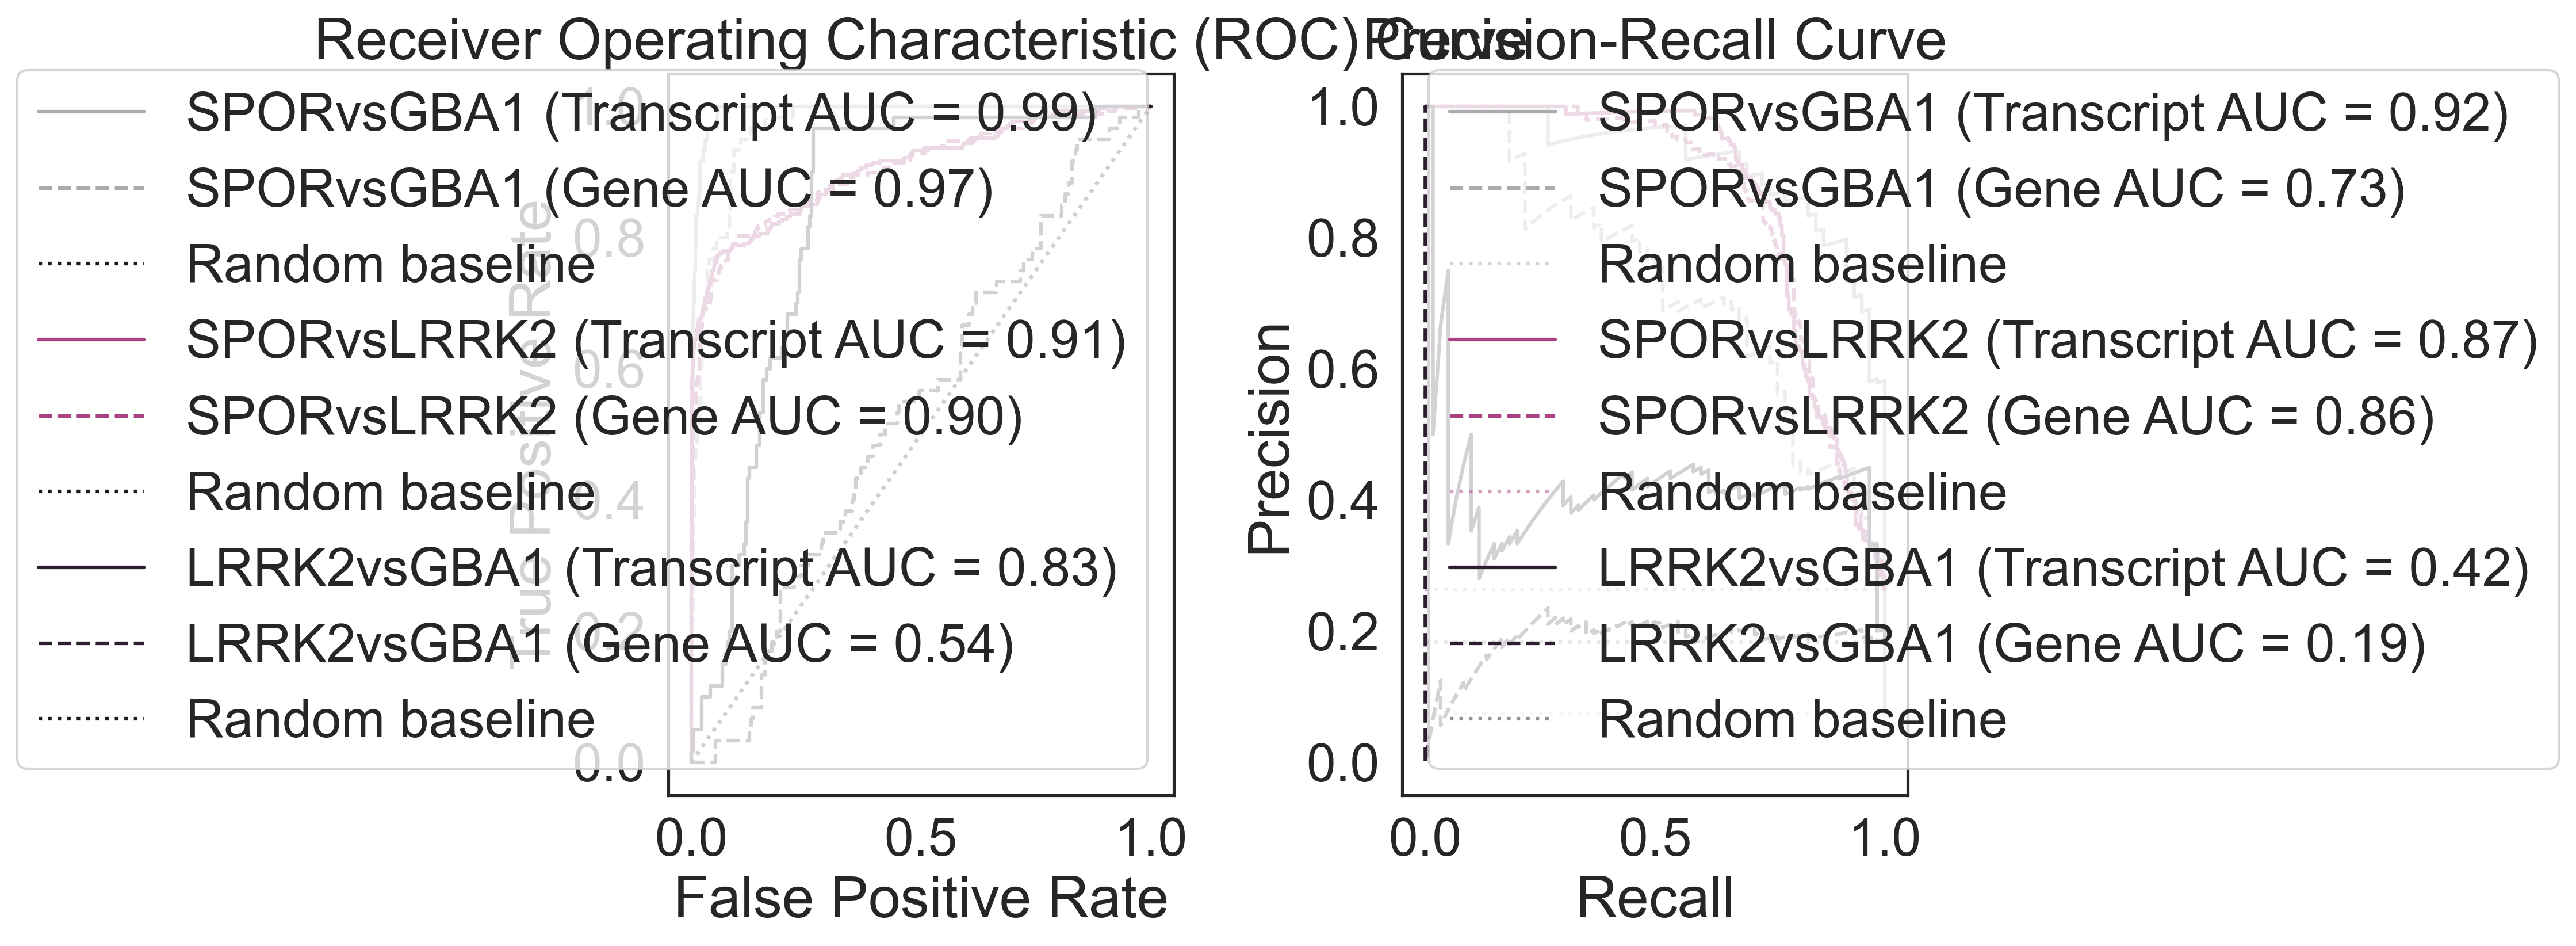

In [33]:

# Plot ROC Curve
plt.figure(figsize=(14, 6))

verse="LRRK2"
palette={"%svsGBA1"%verse:"#2D1E2F",  "SPORvs%s"%verse:"#AB4283","SPORvsGBA1":"#ababab"}
sns.set(style="white", font_scale=2)
for key, (av,yy) in dico_res.items():
    # ROC Curve
    fpr, tpr, roc_thresholds = roc_curve(yy, av)
    roc_auc = auc(fpr, tpr)

    av_g,yy_g, = dico_res_blood[key]
    fpr_g, tpr_g, roc_thresholds_g = roc_curve(yy_g, av_g)
    roc_auc_g = auc(fpr_g, tpr_g)

    # Precision-Recall Curve
    precision, recall, prc_thresholds = precision_recall_curve(yy, av)
    prc_auc = auc(recall, precision)

    precision_g, recall_g, prc_thresholds_g = precision_recall_curve(yy_g, av_g)
    prc_auc_g = auc(recall_g, precision_g)

    prevalence = len(np.asarray(yy)[np.asarray(yy)==1])/len(yy)

    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, label=f"{key} (Transcript AUC = {roc_auc:.2f})", 
             color=palette[key])
    plt.plot(fpr_g, tpr_g, label=f"{key} (Gene AUC = {roc_auc_g:.2f})",
             color=palette[key], linestyle="--")

    plt.plot([0, 1], [0, 1], 'k:', label="Random baseline")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Receiver Operating Characteristic (ROC) Curve")
    plt.legend(loc="lower right")
    # plt.grid()
    
    # Plot PRC Curve
    plt.subplot(1, 2, 2)
    plt.plot(recall, precision, label=f"{key} (Transcript AUC = {prc_auc:.2f})",
             color=palette[key])
    plt.plot(recall_g, precision_g, label=f"{key} (Gene AUC = {prc_auc_g:.2f})", 
             color=palette[key], linestyle="--")
    plt.plot([0, 1], [prevalence, prevalence], color=palette[key],linestyle=':',alpha=0.5, label="Random baseline")
    
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.legend(loc="lower left")
    # plt.grid(False)
    
    plt.tight_layout()

plt.savefig("./outdir/roc_prc_multivariate_blood_transcripts.svg")
plt.show()

In [17]:
v1 = "SPOR"
v2 = "GBA1"
adata_pd.obs.reset_index(drop=True, inplace=True)
av, y = dico_res["%svs%s"%(v1,v2)]
df_res = pd.DataFrame(av, columns=["mean prediction"])
df_res["groundtruth"] = y
df_res["Model error"] = np.abs(av.astype(float)-y.astype(float))
adata_pd_g = adata_pd[adata_pd.obs.subgroup.isin([v1, v2])]

for it in adata_pd_g.obs.columns :
    df_res[it] = adata_pd_g.obs[it].tolist()


/var/folders/yn/qvpxfrdd5870gxhq9hf9jvc40000gq/T/ipykernel_17553/1263971828.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_res[it] = adata_pd_g.obs[it].tolist()
/var/folders/yn/qvpxfrdd5870gxhq9hf9jvc40000gq/T/ipykernel_17553/1263971828.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_res[it] = adata_pd_g.obs[it].tolist()
/var/folders/yn/qvpxfrdd5870gxhq9hf9jvc40000gq/T/ipykernel_17553/1263971828.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many 

In [18]:
df_res[df_res.subgroup=="GBA1"]

,mean prediction,groundtruth,Model error,study,PATNO,EVENT_ID,sampleID,seqID,assay,level,...,brain_region,PatientID,condition,LRRK2_mutation,GBA_mutation,VPS35_mutation,SNCA_mutation,PRKN_mutation,PARK7_mutation,PINK1_mutation
3,0.943091,1,0.056909,PPMI-Phase2-IR3,55875,BL,0002988101,5104-SL-3866,longRNA-NEBKAP,transcripts,...,blood,55875,GBA1,0,N409S,0,0,0,0,0
4,0.238799,1,0.761201,PPMI-Phase2-IR3,55615,BL,0002326783,5104-SL-2839,longRNA-NEBKAP,transcripts,...,blood,55615,GBA1,0,N409S,0,0,0,0,0
5,0.730175,1,0.269825,PPMI-Phase2-IR3,58510,BL,0003419479,5104-SL-4069,longRNA-NEBKAP,transcripts,...,blood,58510,GBA1,0,N409S,0,0,0,0,0
9,0.874209,1,0.125791,PPMI-Phase2-IR3,53600,BL,0002326767,5104-SL-3224,longRNA-NEBKAP,transcripts,...,blood,53600,GBA1,0,N409S,0,0,0,0,0
11,0.681833,1,0.318167,PPMI-Phase2-IR3,53339,BL,0003401519,5104-SL-3127,longRNA-NEBKAP,transcripts,...,blood,53339,GBA1,0,N409S,0,0,0,0,0
14,0.322853,1,0.677147,PPMI-Phase2-IR3,54144,BL,0001205109,5104-SL-2763,longRNA-NEBKAP,transcripts,...,blood,54144,GBA1,0,N409S,0,0,0,0,0
16,0.104515,1,0.895485,PPMI-Phase2-IR3,40338,BL,0001094747,5104-SL-3060,longRNA-NEBKAP,transcripts,...,blood,40338,GBA1,0,N409S,0,0,0,0,0
18,0.728017,1,0.271983,PPMI-Phase2-IR3,52678,BL,0001083579,5104-SL-3117,longRNA-NEBKAP,transcripts,...,blood,52678,GBA1,0,N409S,0,0,0,0,0
25,0.639048,1,0.360952,PPMI-Phase2-IR3,51731,BL,0000953384,5104-SL-3067,longRNA-NEBKAP,transcripts,...,blood,51731,GBA1,0,N409S,0,0,0,0,0
26,0.512268,1,0.487732,PPMI-Phase2-IR3,54695,BL,0002944245,5104-SL-3640,longRNA-NEBKAP,transcripts,...,blood,54695,GBA1,0,N409S,0,0,0,0,0


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

GBA1_No Treatment vs. GBA1_Treatment: Mann-Whitney-Wilcoxon test two-sided with Holm-Bonferroni correction, P_val:8.393e-01 U_stat=1.950e+02
SPOR_No Treatment vs. SPOR_Treatment: Mann-Whitney-Wilcoxon test two-sided with Holm-Bonferroni correction, P_val:3.515e-02 (ns) U_stat=6.371e+04


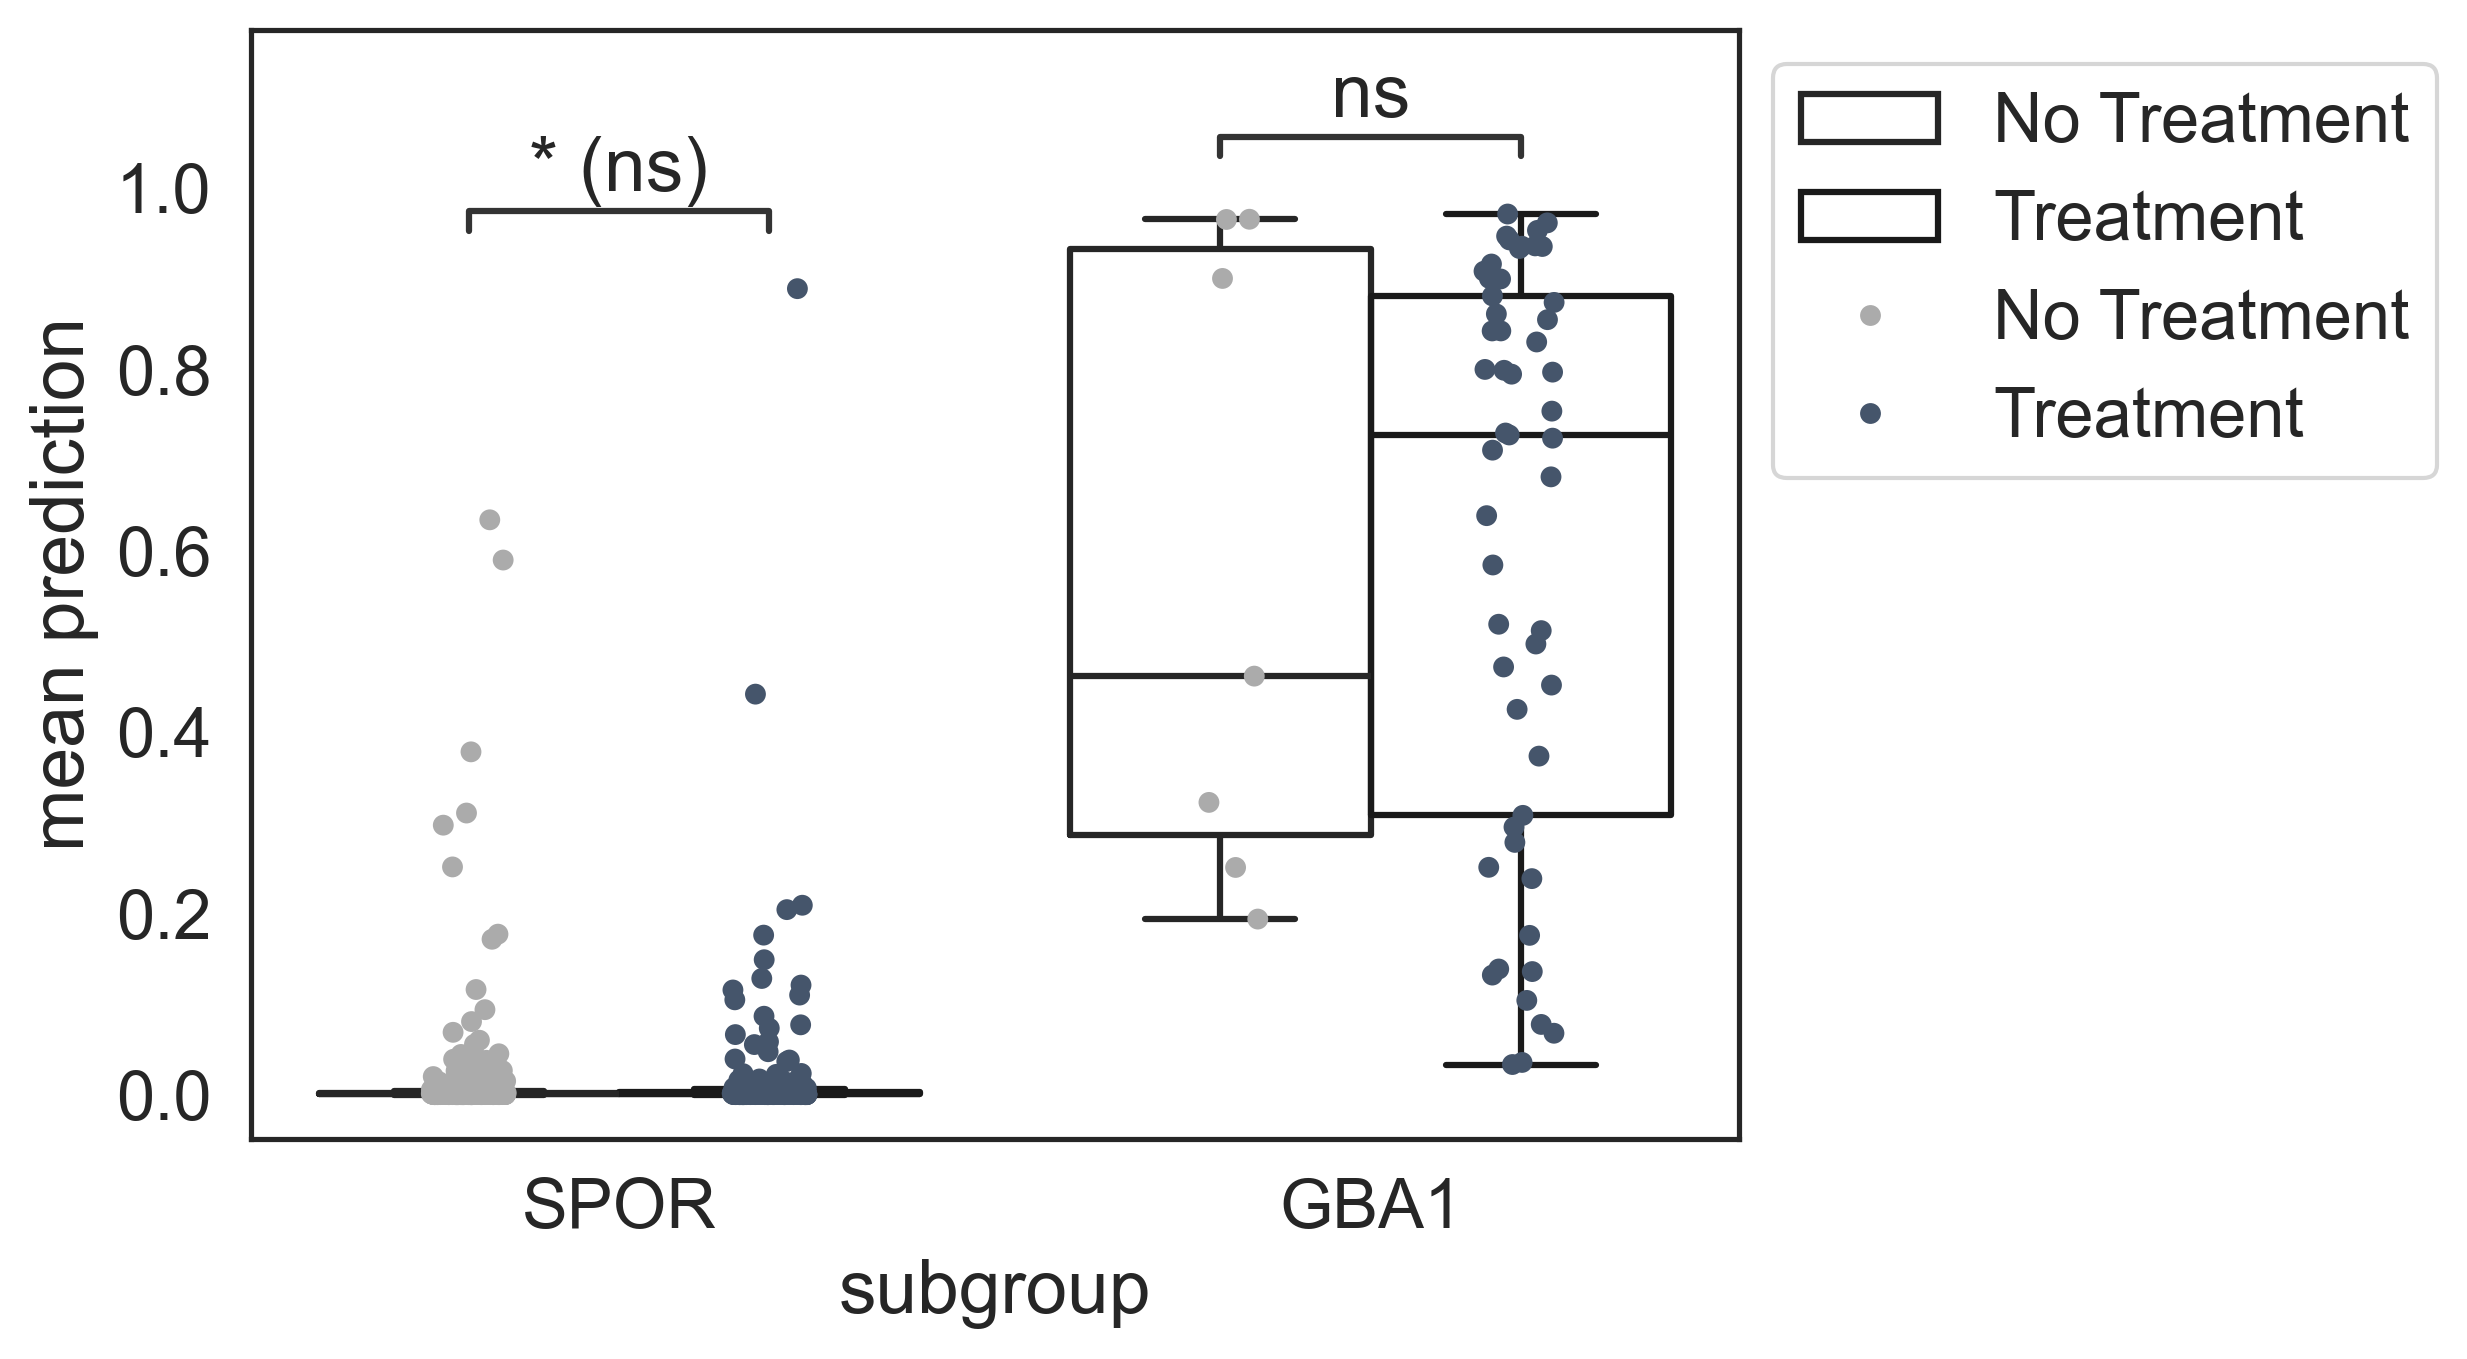

In [21]:
df_res["Under dopaminergic medication"] = df_res['PDTRTMNT'].map({0:"No Treatment",1:"Treatment"})
COLORS_CT["No Treatment"] = "#ababab"
COLORS_CT["Treatment"] = COLORS_CT["Female"]

fig, ax = plt.subplots()
sns.boxplot(data=df_res, x="subgroup", y="mean prediction", hue="Under dopaminergic medication", 
            dodge=True, ax=ax, fill=False, color="k",showfliers=False)

sns.stripplot(data=df_res, x="subgroup", y="mean prediction", hue="Under dopaminergic medication", 
              dodge=True, ax=ax, palette=COLORS_CT)

pairs = [(("GBA1","Treatment"),("GBA1","No Treatment")),
          (("SPOR","Treatment"),("SPOR","No Treatment"))]
annotator= Annotator(data=df_res, x="subgroup", y="mean prediction", 
                     hue="Under dopaminergic medication",
                     ax=ax, pairs=pairs)
annotator.configure(test='Mann-Whitney', text_format='star',comparisons_correction='Holm-Bonferroni')
annotator.apply_and_annotate()
ax.legend(bbox_to_anchor=(1,1))
plt.savefig("outdir/bulk_blood_model_treatment_differences.svg")


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

GBA1_Male vs. GBA1_Female: Mann-Whitney-Wilcoxon test two-sided with Holm-Bonferroni correction, P_val:3.888e-01 U_stat=5.040e+02
SPOR_Male vs. SPOR_Female: Mann-Whitney-Wilcoxon test two-sided with Holm-Bonferroni correction, P_val:6.348e-02 U_stat=6.593e+04


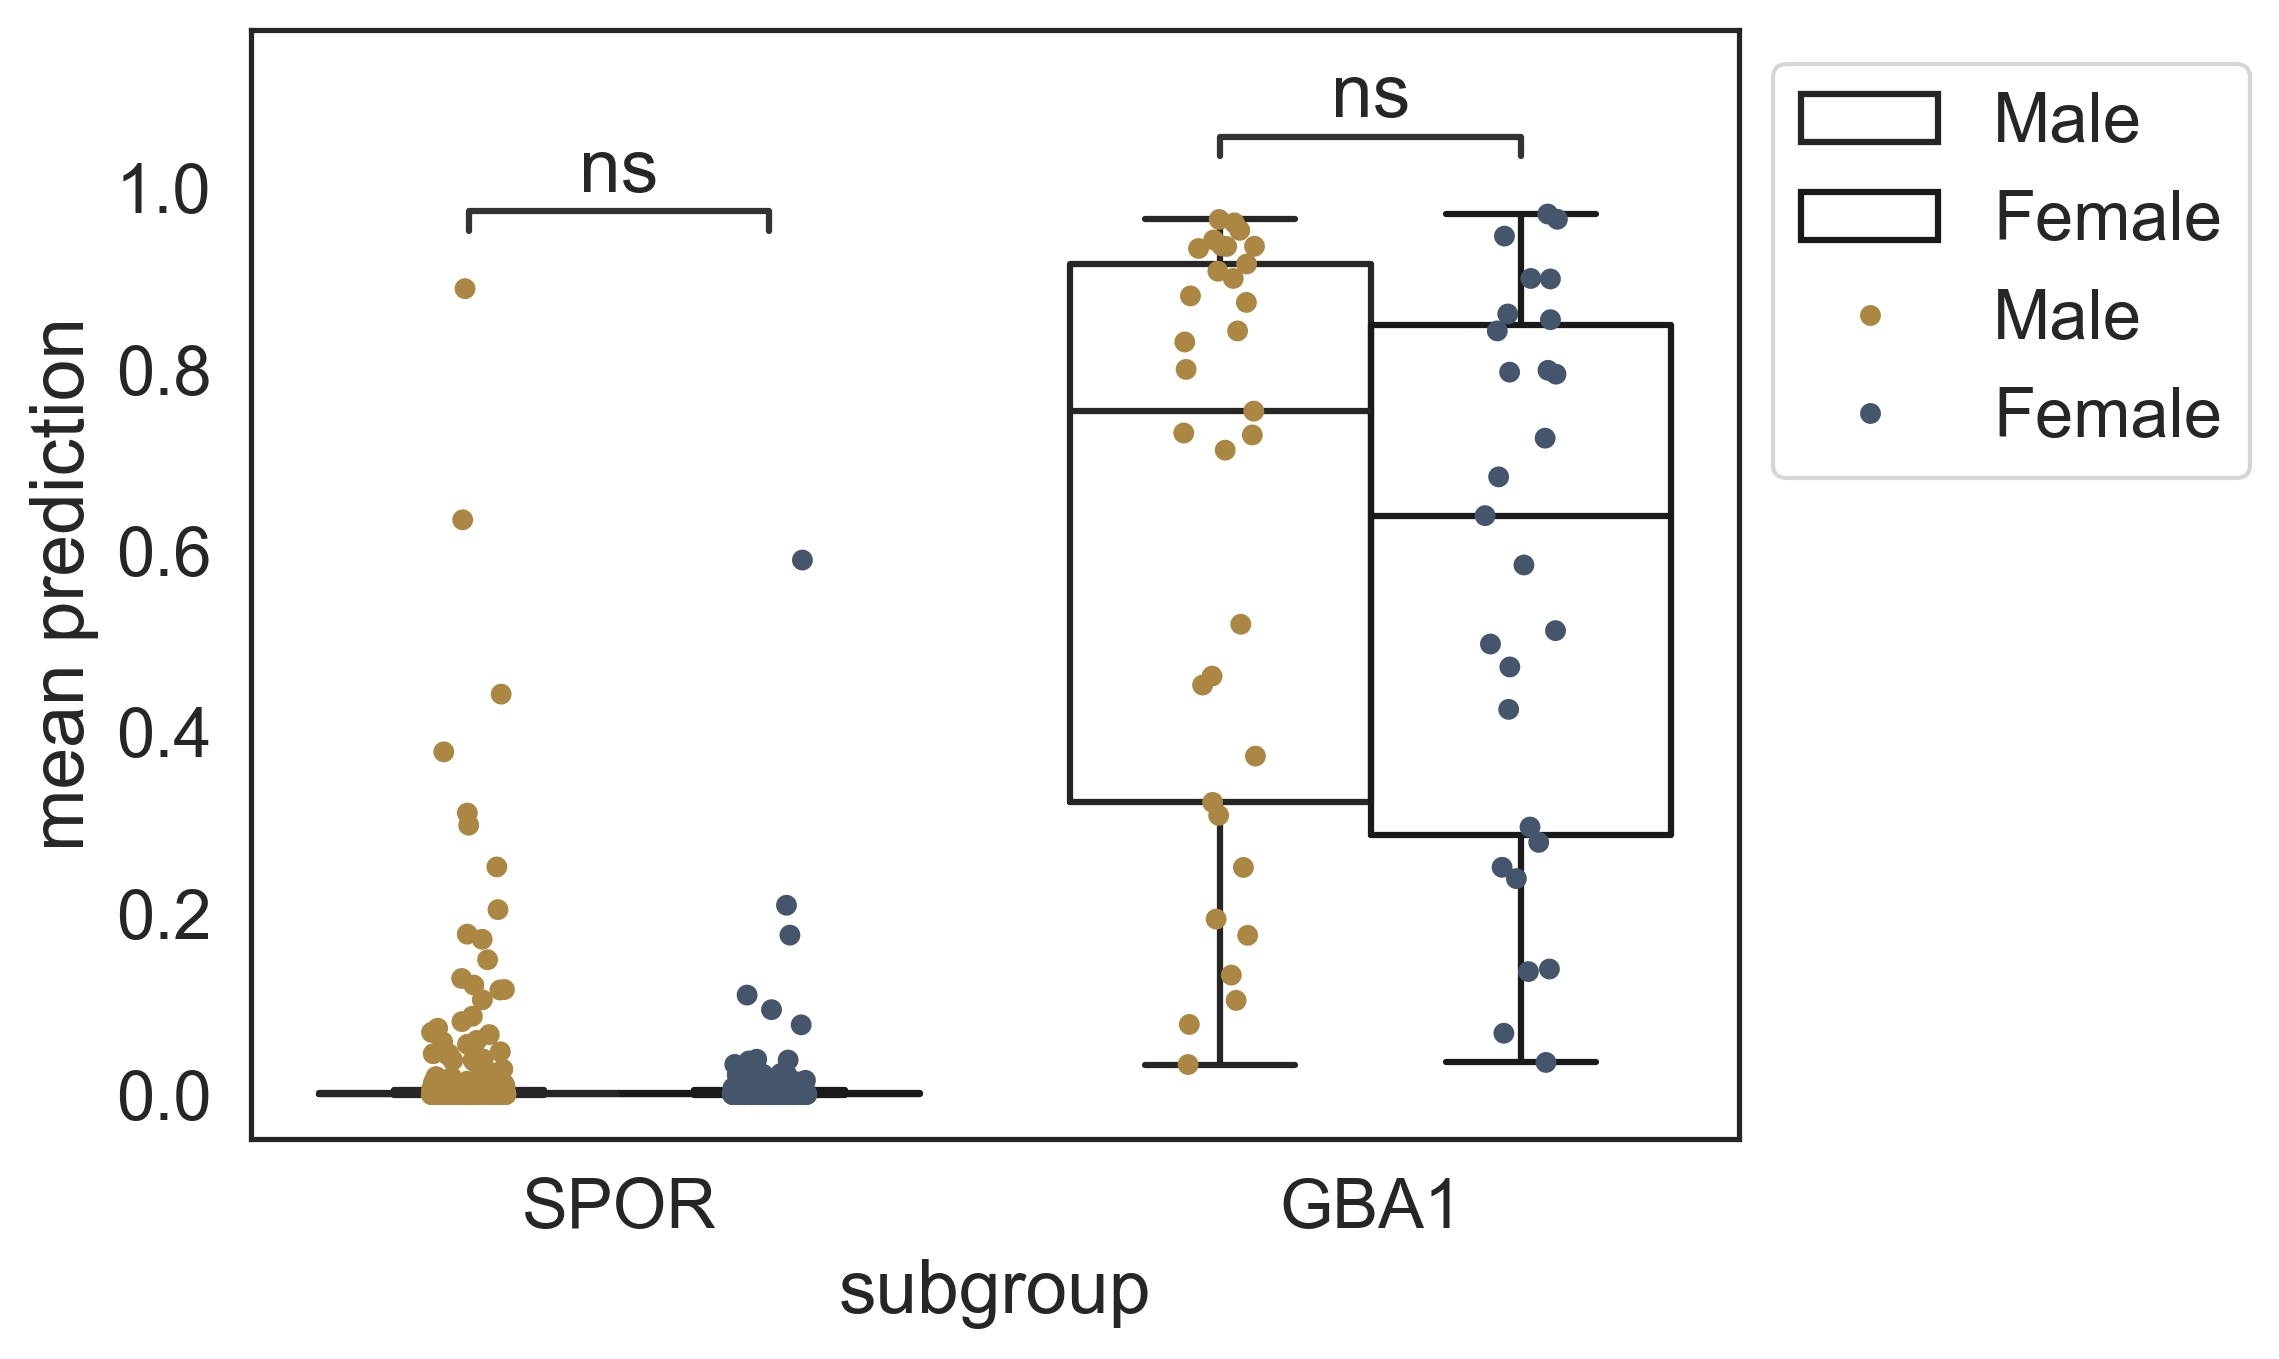

In [22]:
df_res["Sex"] =df_res["SEX"].map({0:"Female", 1:"Male"})
fig, ax = plt.subplots()
sns.boxplot(data=df_res, x="subgroup", y="mean prediction", hue="Sex", 
            dodge=True, ax=ax, fill=False, color="k", showfliers=False)

sns.stripplot(data=df_res, x="subgroup", y="mean prediction", 
              hue="Sex", dodge=True, palette=COLORS_CT)
pairs = [(("GBA1","Female"),("GBA1","Male")),
          (("SPOR","Female"),("SPOR","Male"))]
annotator= Annotator(data=df_res, x="subgroup", y="mean prediction", 
                     hue="Sex",
                     ax=ax, pairs=pairs)
annotator.configure(test='Mann-Whitney', text_format='star',comparisons_correction='Holm-Bonferroni')
annotator.apply_and_annotate()
ax.legend(bbox_to_anchor=(1,1))
plt.savefig("outdir/bulk_blood_model_sex_differences.svg")


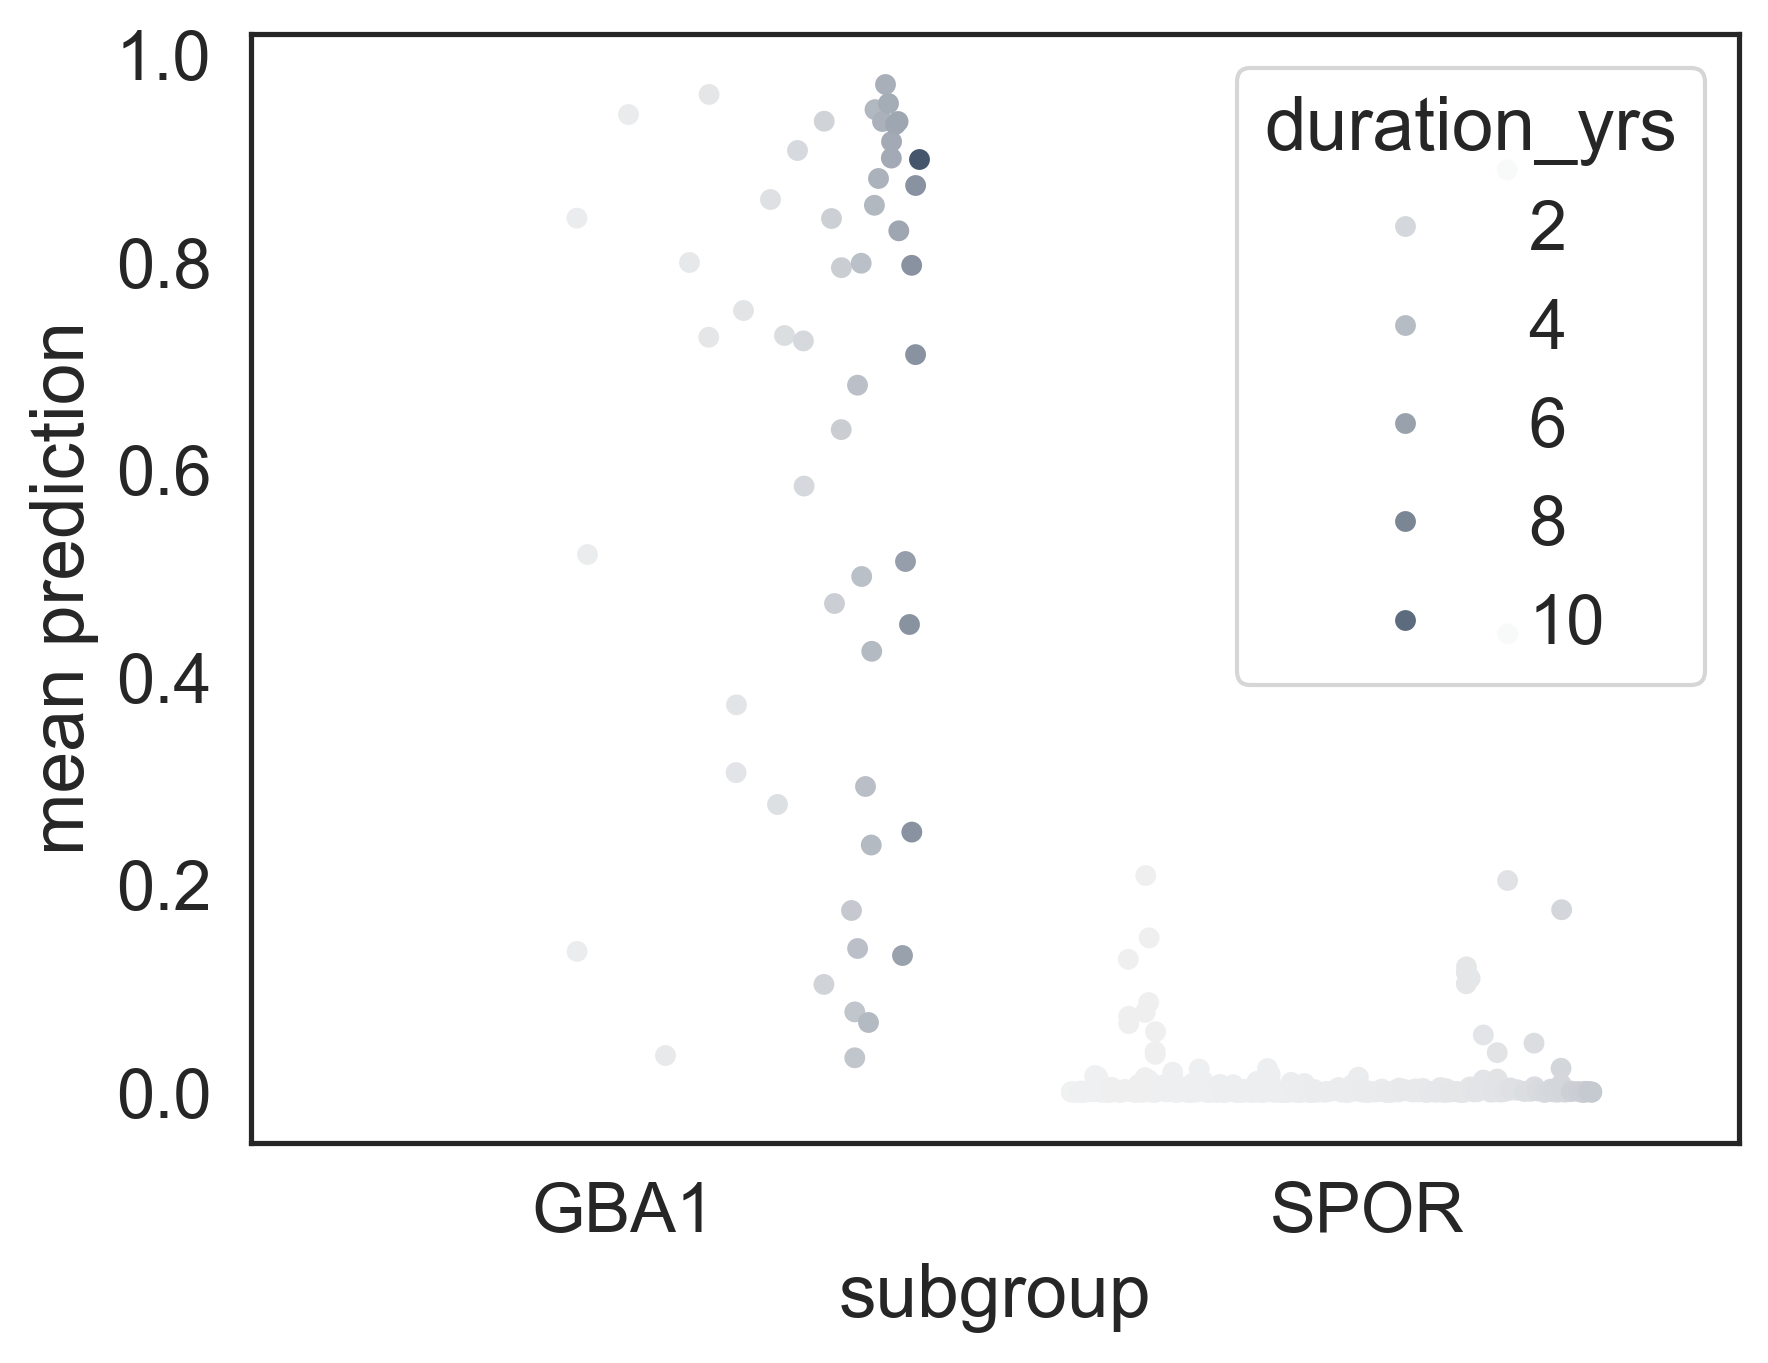

In [23]:
# df_res["Disease duration"] = df_res["fampd"].map({1:"1st Degree Family w/PD",
#                                                 2:"Non-1st Degree Family w/PD",
#                                                 3:"No Family w/PD"})

sns.stripplot(data=df_res[df_res.PDTRTMNT==1], x="subgroup", y="mean prediction", hue="duration_yrs",  dodge=True, palette=cmap)
ax.legend(bbox_to_anchor=(1,1))

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

GBA1_No Family w/PD vs. GBA1_1st Degree Family w/PD: Mann-Whitney-Wilcoxon test two-sided with Holm-Bonferroni correction, P_val:5.549e-04 U_stat=4.750e+02
SPOR_No Family w/PD vs. SPOR_1st Degree Family w/PD: Mann-Whitney-Wilcoxon test two-sided with Holm-Bonferroni correction, P_val:2.069e-01 U_stat=3.361e+04


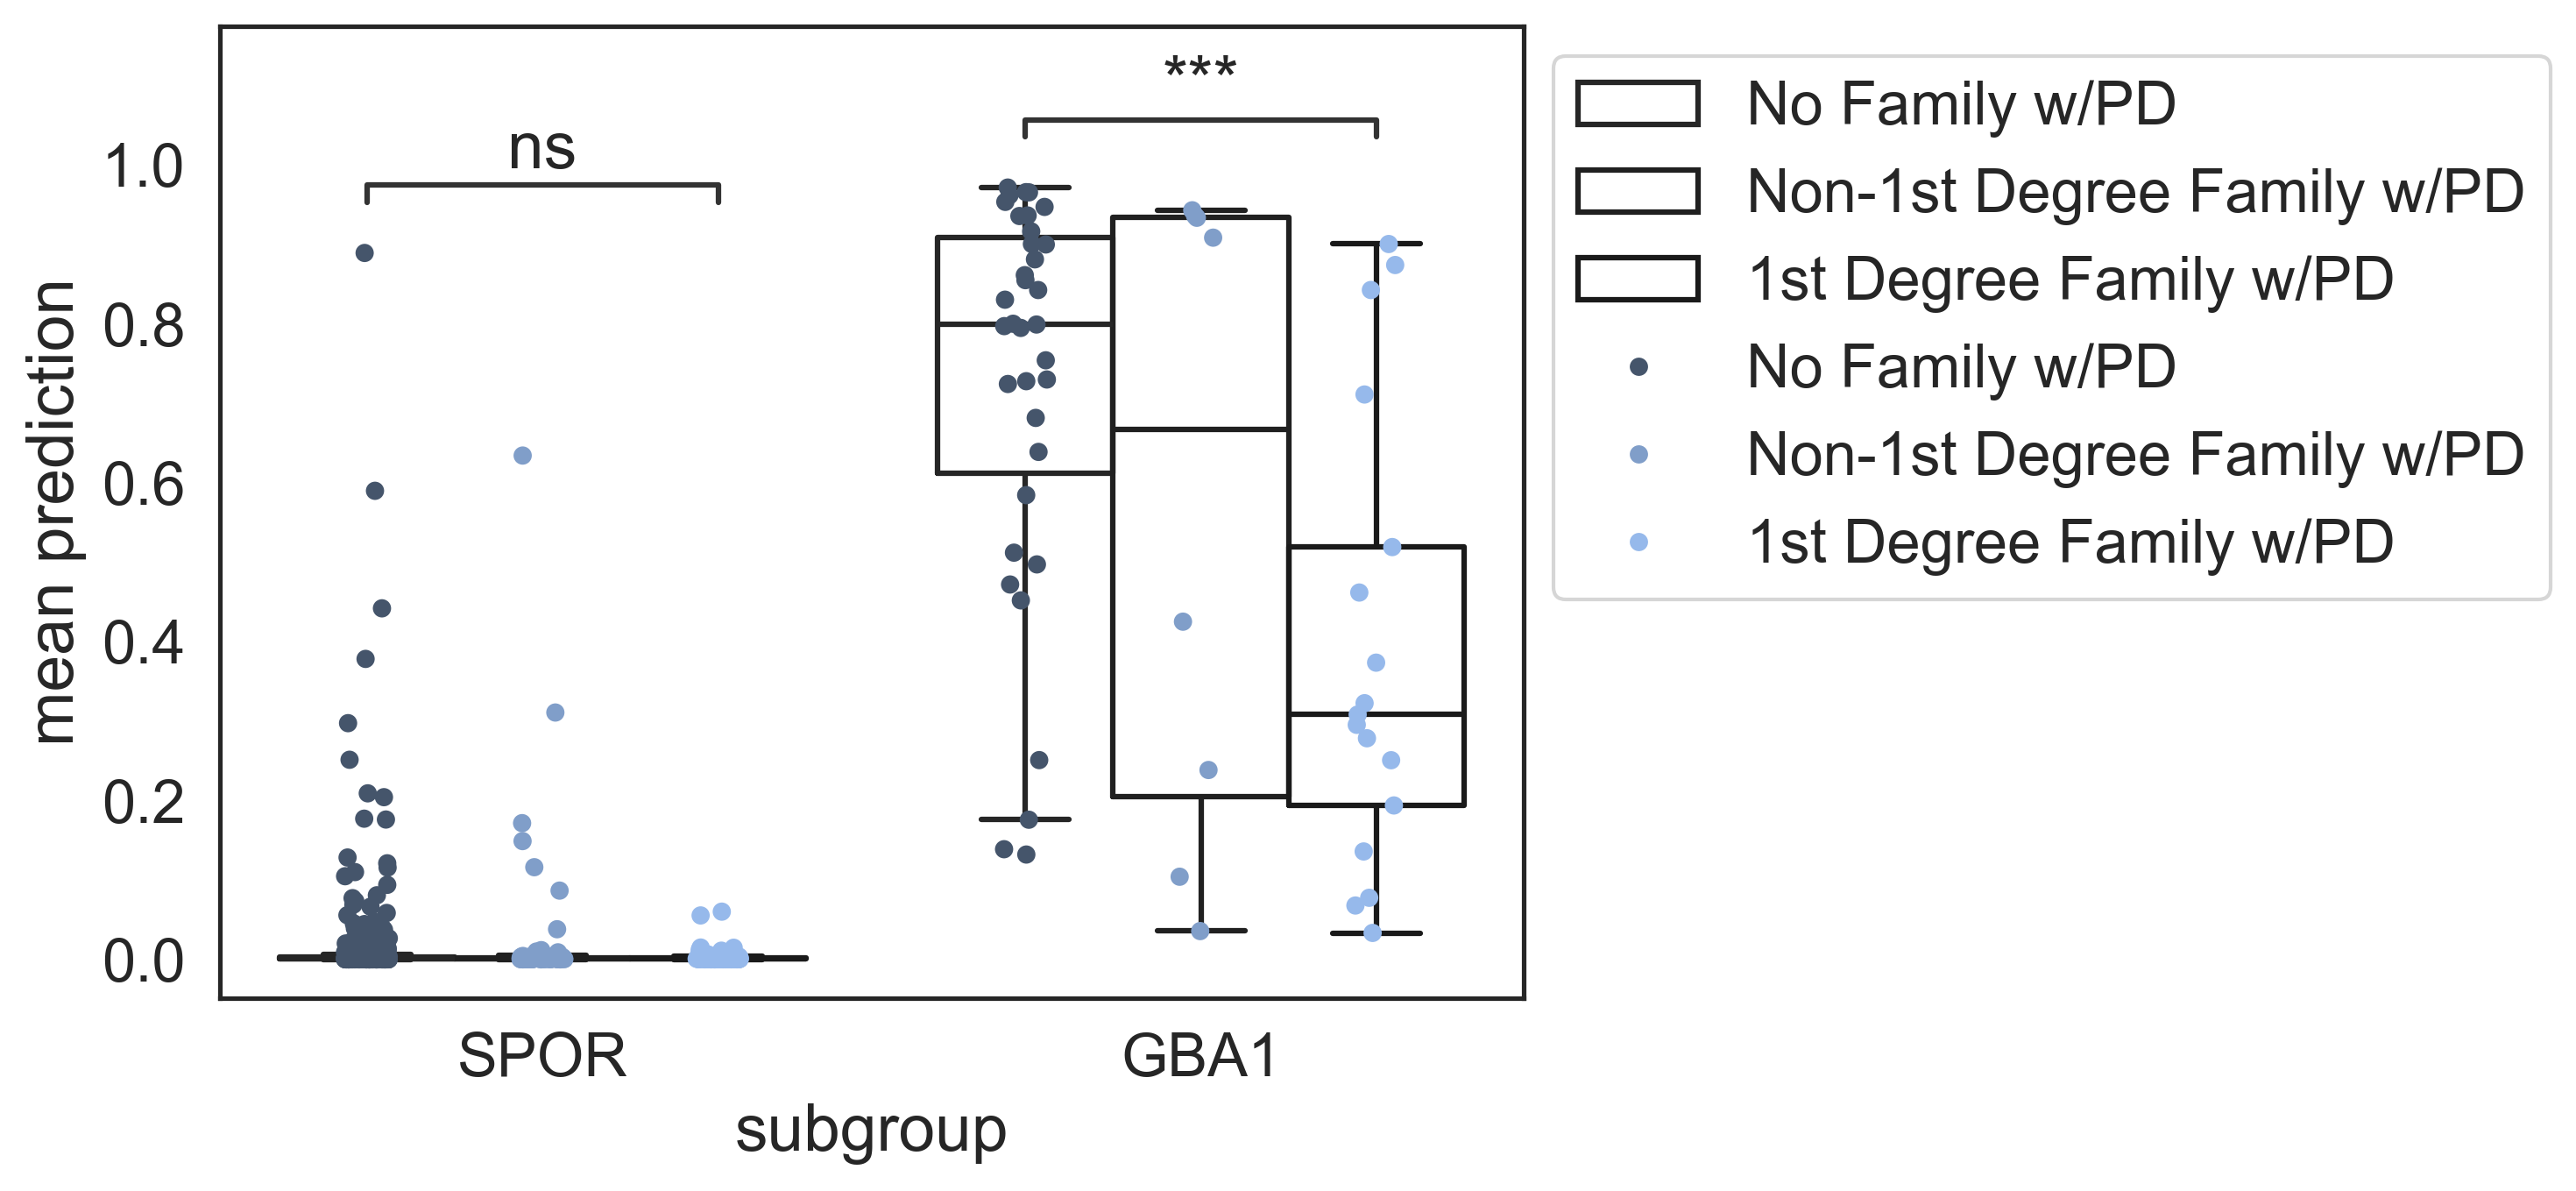

In [25]:
df_res["Family History"] = df_res["fampd"].map({1:"1st Degree Family w/PD",
                                                2:"Non-1st Degree Family w/PD",
                                                3:"No Family w/PD"})
COLORS_CT["No Family w/PD"] = "#45556B"
COLORS_CT["Non-1st Degree Family w/PD"] = "#809EC9"
COLORS_CT["1st Degree Family w/PD"] = "#96B9EB"
fig, ax = plt.subplots()
sns.boxplot(data=df_res, x="subgroup", y="mean prediction", 
            hue="Family History",  dodge=True, color="k", fill=False, ax=ax, showfliers=False)
sns.stripplot(data=df_res, x="subgroup", y="mean prediction",
              hue="Family History",  dodge=True,  ax=ax, palette=COLORS_CT)
pairs = [(("GBA1","No Family w/PD"),("GBA1","1st Degree Family w/PD")),
          (("SPOR","No Family w/PD"),("SPOR","1st Degree Family w/PD"))]
annotator= Annotator(data=df_res, x="subgroup", y="mean prediction", 
                     hue="Family History",
                     ax=ax, pairs=pairs)
annotator.configure(test='Mann-Whitney', text_format='star',comparisons_correction='Holm-Bonferroni')
annotator.apply_and_annotate()
ax.legend(bbox_to_anchor=(1,1))
plt.savefig("outdir/bulk_blood_model_fmiliy_history_differences.svg")


In [ ]:
# df_res["Family History"] = df_res["fampd"].map({1:"1st Degree Family w/PD",
#                                                 2:"Non-1st Degree Family w/PD",
#                                                 3:"No Family w/PD"})
# COLORS_CT["No Family w/PD"] = "#45556B"
# COLORS_CT["Non-1st Degree Family w/PD"] = "#809EC9"
# COLORS_CT["1st Degree Family w/PD"] = "#96B9EB"
fig, ax = plt.subplots()
sns.boxplot(data=df_res, x="subgroup", y="mean prediction", 
            hue="EDUCYRS",  dodge=True, color="k", fill=False, ax=ax, showfliers=False)
sns.stripplot(data=df_res, x="subgroup", y="mean prediction",
              hue="EDUCYRS",  dodge=True,  ax=ax)#, palette=COLORS_CT)
# pairs = [(("GBA1","No Family w/PD"),("GBA1","1st Degree Family w/PD")),
#           (("SPOR","No Family w/PD"),("SPOR","1st Degree Family w/PD"))]
# annotator= Annotator.Annotator(data=df_res, x="subgroup", y="mean prediction", 
#                      hue="Family History",
#                      ax=ax, pairs=pairs)
# annotator.configure(test='Mann-Whitney', text_format='star',comparisons_correction='Holm-Bonferroni')
# annotator.apply_and_annotate()
ax.legend(bbox_to_anchor=(1,1))

In [ ]:
ax = sns.stripplot(data=df_res, x="subgroup", y="mean prediction", hue="GBA_mutation",  dodge=True)
ax.legend(bbox_to_anchor=(1,1))

-0.17631183864879535 1.2020193074497185e-06


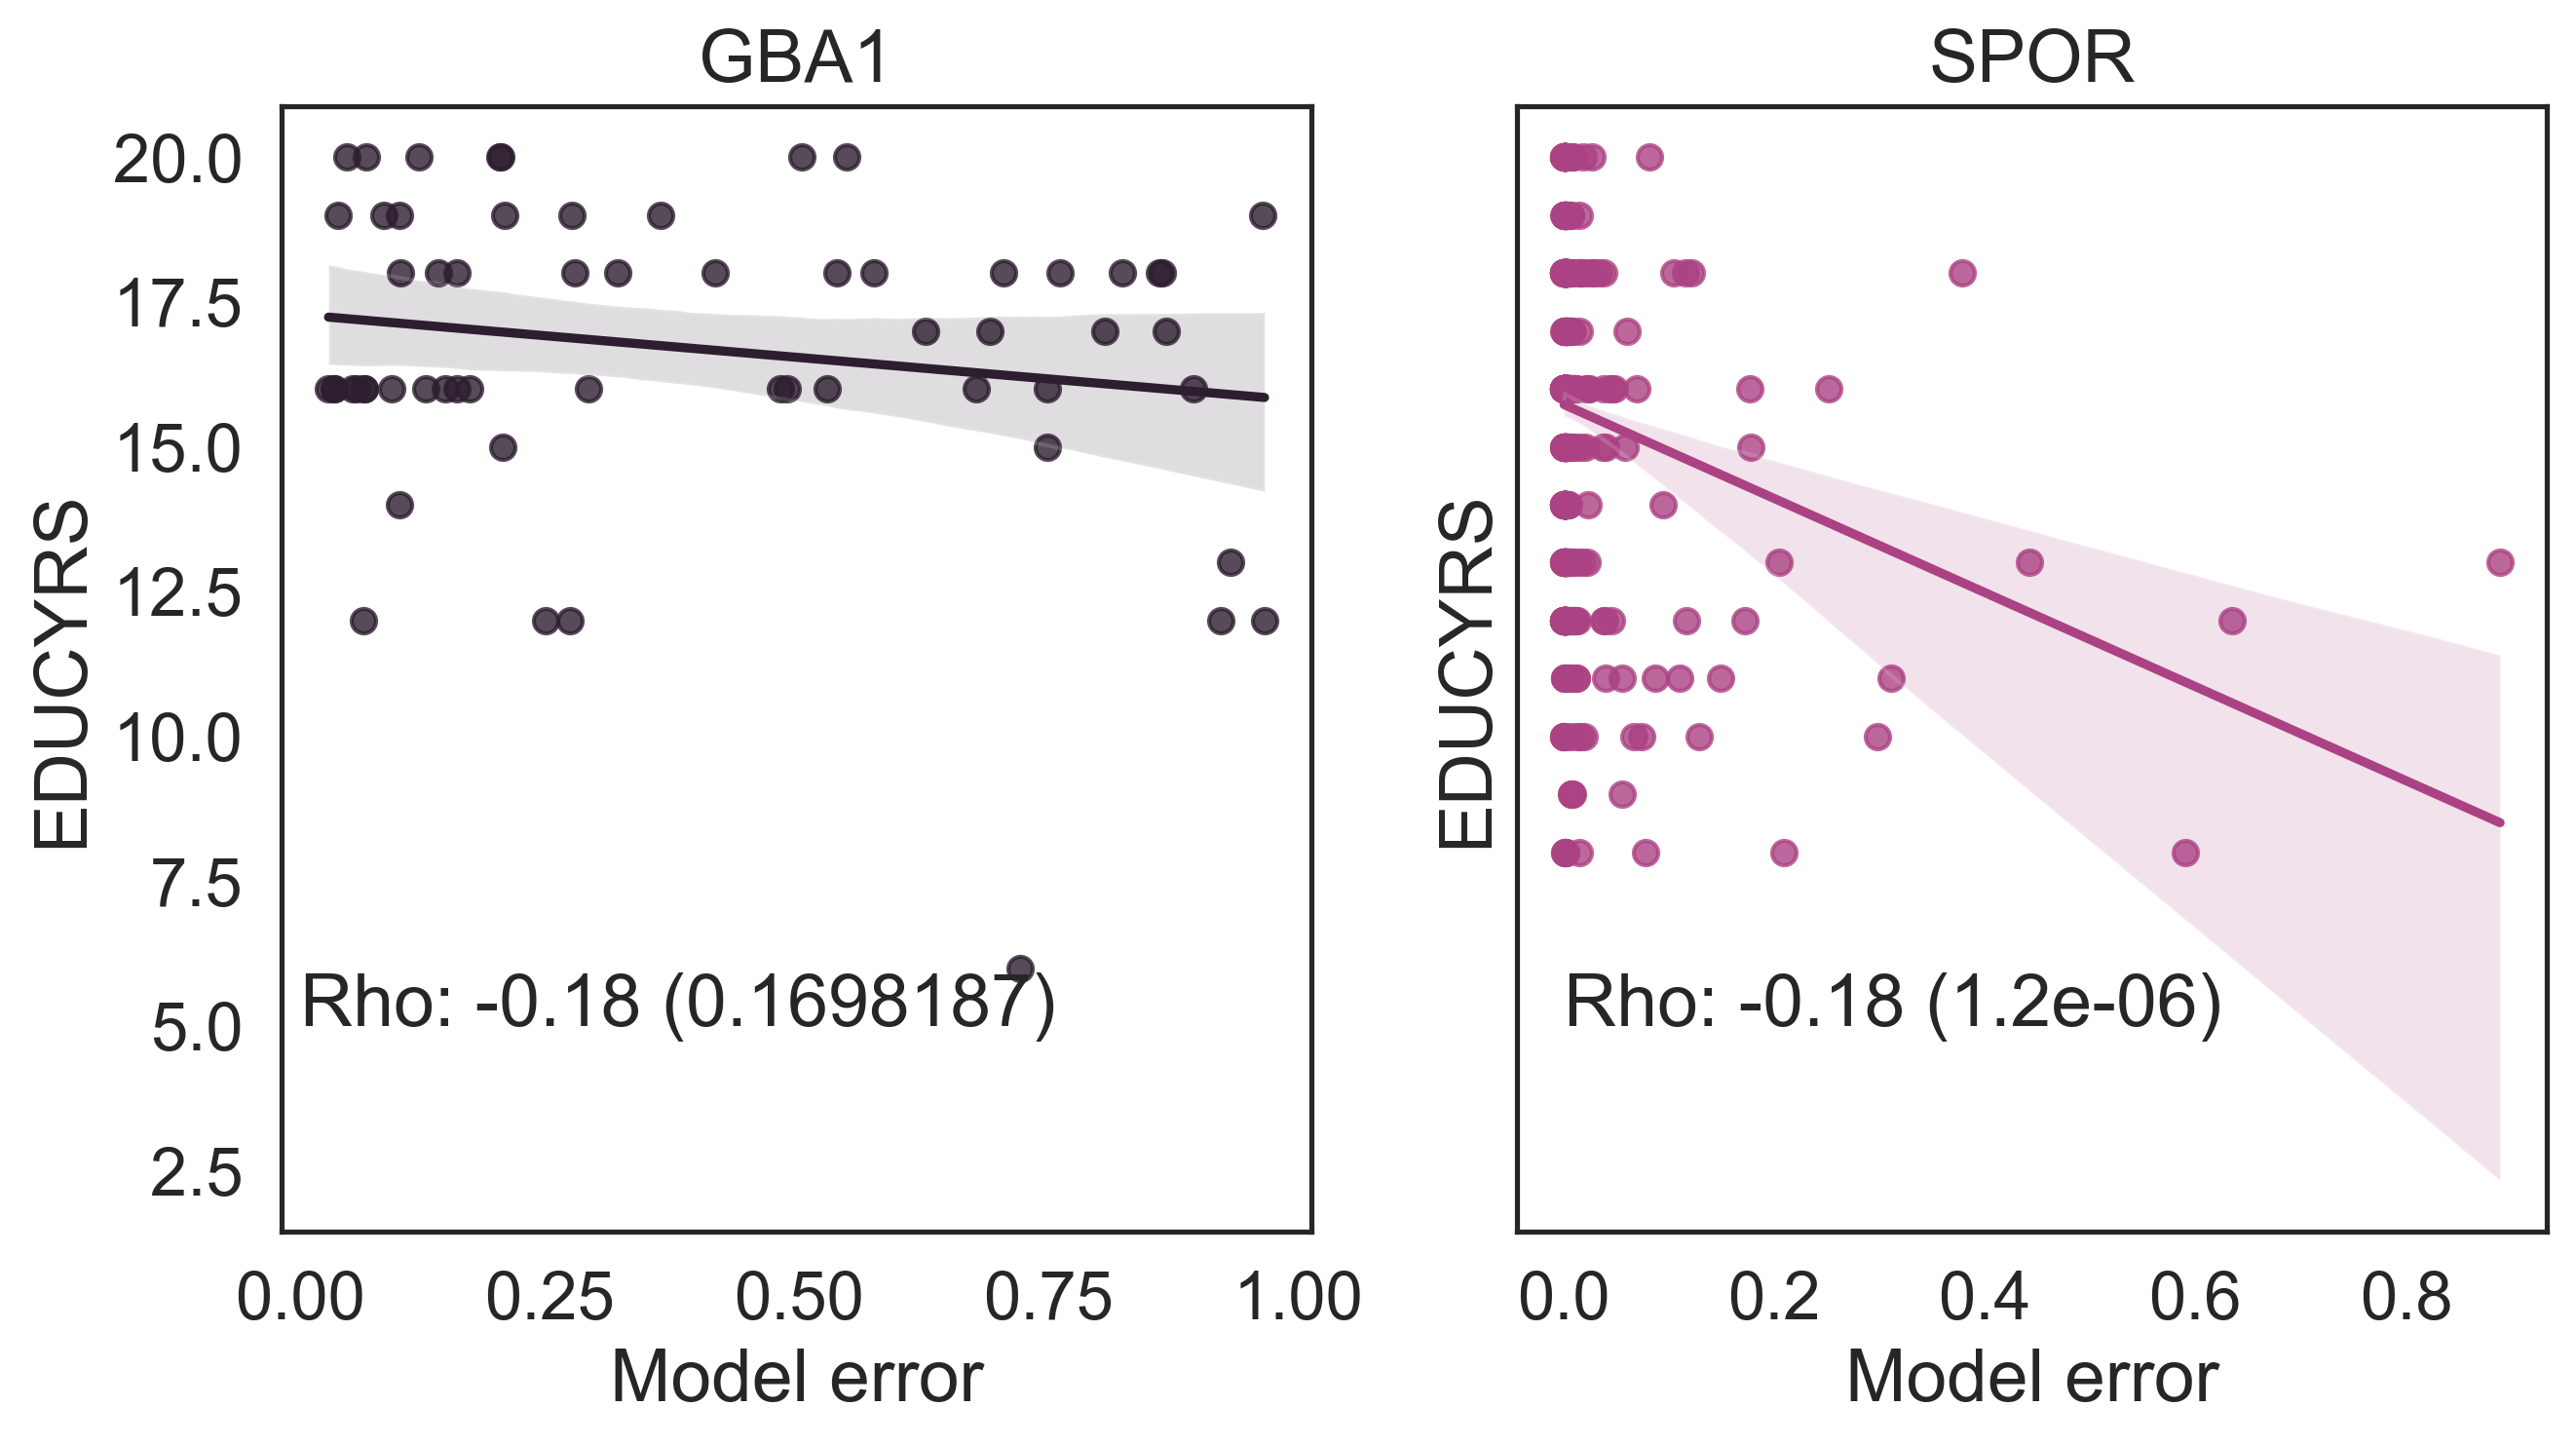

In [26]:
var="EDUCYRS"
meth = pearsonr
fig, axes = plt.subplots(1,2,figsize=(10,5),sharey=True)
tmp1 =df_res[df_res.subgroup=="GBA1"]
tmp1 = tmp1[~tmp1[var].isna()]
sns.regplot(data=tmp1, x="Model error", y=var, 
            color=COLORS_CT["GBA1"], 
           ax=axes[0],)
            #hue="Under dopaminergic medication")
tmp2 =df_res[df_res.subgroup=="SPOR"]
tmp2 = tmp2[~tmp2[var].isna()]
sns.regplot(data=tmp2, x="Model error", y=var,#hue="Under dopaminergic medication",
            color=COLORS_CT["SPOR"], 
           ax=axes[1])

axes[0].set_title("GBA1")
axes[1].set_title("SPOR")

sp , p = meth(tmp1["Model error"], tmp1[var])
axes[0].text(0,5, "Rho: %s (%s)"%(str(np.round(sp,2)),str(np.round(p,7))))


sp , p = meth(tmp2["Model error"], tmp2[var])
axes[1].text(0,5, "Rho: %s (%s)"%(str(np.round(sp,2)),str(np.round(p,7))))
print(sp, p)

plt.savefig("outdir/bulk_blood_model_%s_differences.svg"%var)

# sns.regplot(data=df_res, x="error", y="duration",color="grey", ax=ax)

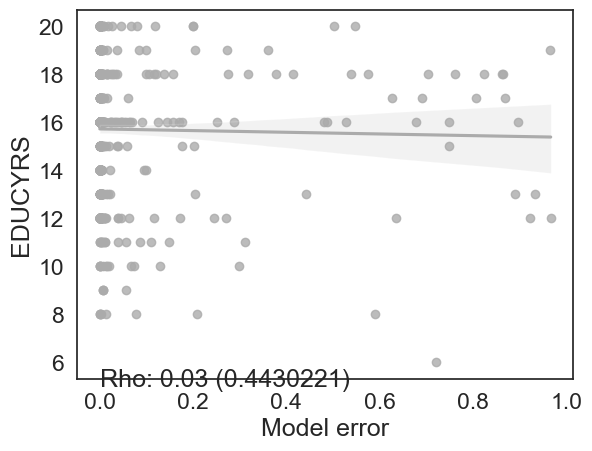

In [49]:
var="EDUCYRS"
meth = spearmanr
fig, ax = plt.subplots()
tmp = df_res[~df_res[var].isna()]
# tmp = tmp[tmp.subgroup=="GBA1"]
sns.regplot(data=tmp, x="Model error", y=var,
            color="#ababab", ax=ax)


sp , p = meth(tmp["Model error"], tmp[var])
ax.text(0,5, "Rho: %s (%s)"%(str(np.round(sp,2)),str(np.round(p,7))))


plt.savefig("outdir/bulk_blood_model_%s_differences_combined.svg"%var)

In [53]:


adata_pd_g.obs.columns.tolist()
root="/Volumes/U32 Shadow/data/ATAC-seq/PPMI/Subject_Demographics/"
dico_feat = pd.read_excel(os.path.join(root, "PPMI_Curated_Data_Cut_Public_20240729.xlsx"), 
                          sheet_name="Data dictionary")[["Variable", "Category", "Description"]].drop_duplicates()
dico_feat = dico_feat[~dico_feat.Category.isna()]
dico_feat

,Variable,Category,Description
0,SITE,ID,Blinded Site ID
1,PATNO,ID,Participant ID
2,COHORT,ID,Cohort at Enrollment
6,subgroup,ID,List of Subgroup(s) based on enrollment cohort...
7,study_status,ID,PPMI study status
...,...,...,...
366,Stage_Subpark,NSD-ISS,Subthreshold Parkinsonism score - modified MDS...
367,Stage_PDTreat,NSD-ISS,Indicates PD treatment status at visit based o...
369,Stage_S,NSD-ISS,Subject-level a-syn SAA status (Note: Results ...
373,Stage_D,NSD-ISS,Visit-level DAT SBR status - indicates whether...


In [54]:
df_res[df_res.group==group][["Model error"]+cols]

NameError: name 'group' is not defined

/var/folders/yn/qvpxfrdd5870gxhq9hf9jvc40000gq/T/ipykernel_17897/1444705557.py:5: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  p,_ = pearsonr(x,y)
/var/folders/yn/qvpxfrdd5870gxhq9hf9jvc40000gq/T/ipykernel_17897/1444705557.py:10: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  _, pval = pearsonr(x,y)
/var/folders/yn/qvpxfrdd5870gxhq9hf9jvc40000gq/T/ipykernel_17897/1444705557.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


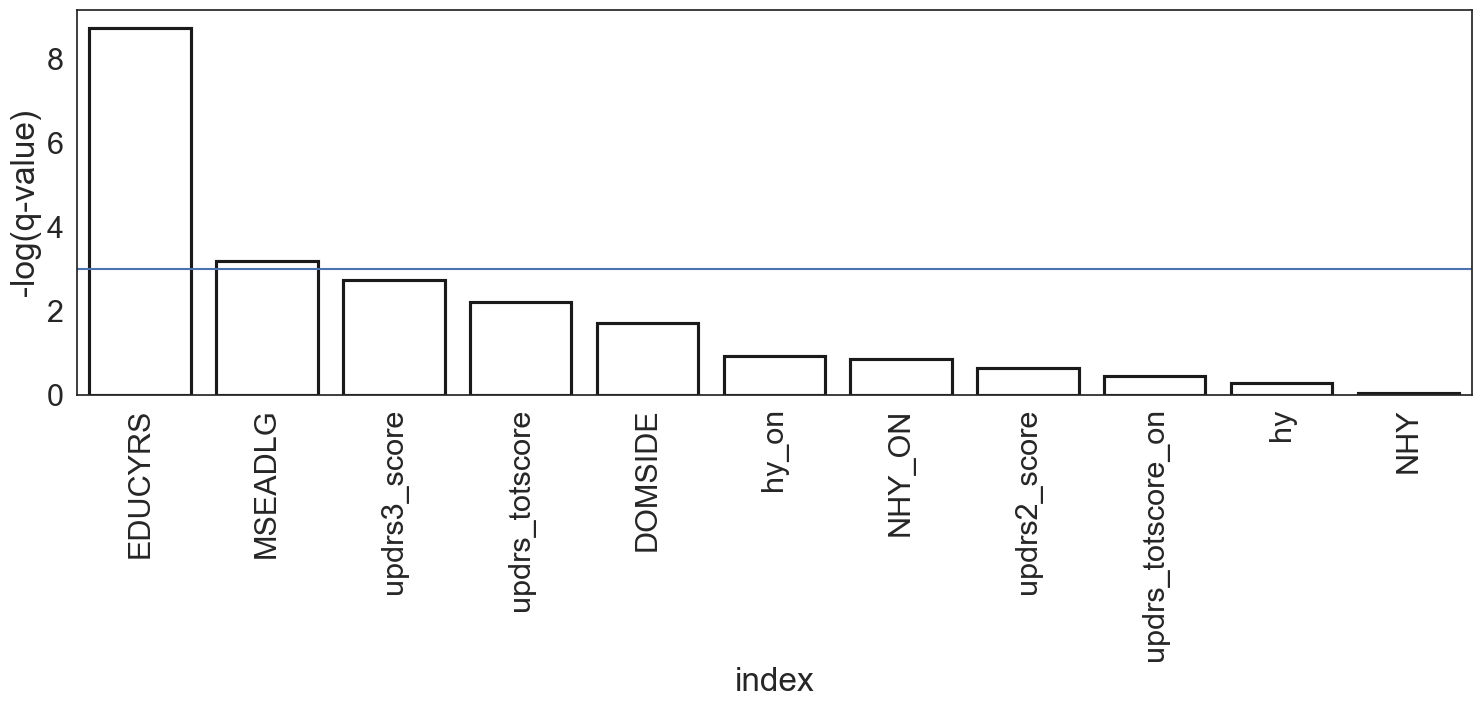

/var/folders/yn/qvpxfrdd5870gxhq9hf9jvc40000gq/T/ipykernel_17897/1444705557.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


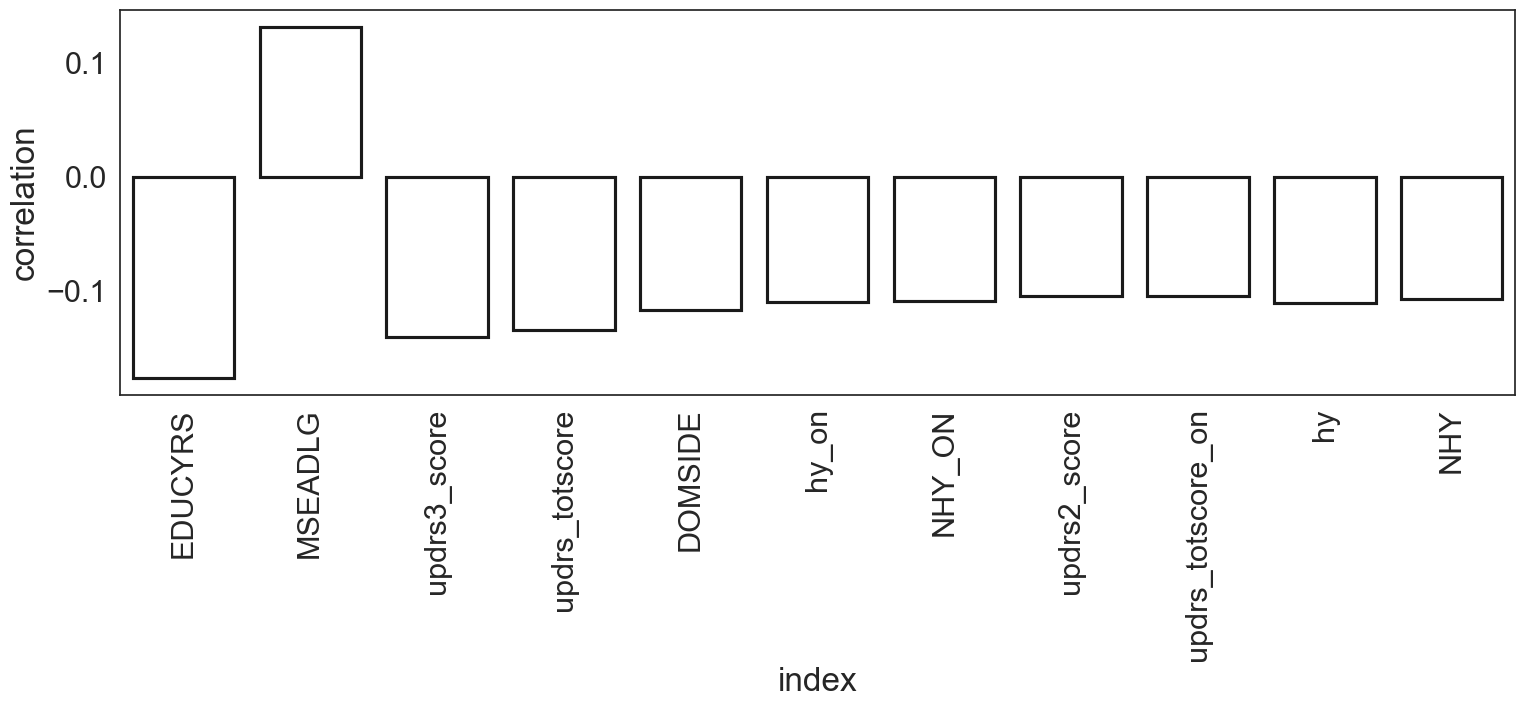

In [55]:
from statsmodels.stats.multitest import multipletests 
meth = pearsonr
def getmeth(x, y):
    # print(x.shape)
    p,_ = pearsonr(x,y)
    return p

def getpvalue(x, y):
    # print(x.shape)
    _, pval = pearsonr(x,y)
    return pval

cols = dico_feat[dico_feat.Category !="ID"].Variable.unique().tolist()
cols = [it for it in cols if it in df_res.columns.tolist()]
toremove = ['APOE', "NSD_STAGE", "Stage_G", "clockdraw", 
            "lexical", "MODBNT", "OTHNEURO", "TMT_A", "TMT_B",
            "howlive", "sex_orient", "updrs4_score"]

cols = [it for it in cols if it not in toremove]
group = "SPOR"
mat = df_res[df_res.group==group][["Model error"]+cols].corr(method=getmeth)
mat = mat.iloc[0, 1:].reset_index()
mat.columns = ["index", "correlation"]
pval = df_res[df_res.group==group][["Model error"]+cols].corr(method=getpvalue)
pval = pval.iloc[0, 1:].reset_index()
pval.columns = ["index", "pval"]
mat = mat.merge(pval, on="index")
_, qval, _, _ = multipletests(mat["pval"].values, method="holm")
mat["qval"] = qval

mat["-log(q-value)"] = -np.log(mat["qval"])
mat

mat = mat.sort_values("-log(q-value)", ascending=False)
sns.set(style="white", font_scale=2)
fig, ax = plt.subplots(figsize=(18,5))
sns.barplot(data=mat[mat.qval<1], x="index", y="-log(q-value)", ax=ax, color="k", fill=False)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
ax.axhline(y=-np.log(0.05))
plt.show()
fig, ax = plt.subplots(figsize=(18,5))
sns.barplot(data=mat[mat.qval<1], x="index", y="correlation", ax=ax, color="k", fill=False)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
plt.show()

/var/folders/yn/qvpxfrdd5870gxhq9hf9jvc40000gq/T/ipykernel_17897/1444705557.py:5: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  p,_ = pearsonr(x,y)
/var/folders/yn/qvpxfrdd5870gxhq9hf9jvc40000gq/T/ipykernel_17897/2629150738.py:5: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  _, pval = pearsonr(x,y)
/var/folders/yn/qvpxfrdd5870gxhq9hf9jvc40000gq/T/ipykernel_17897/2629150738.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


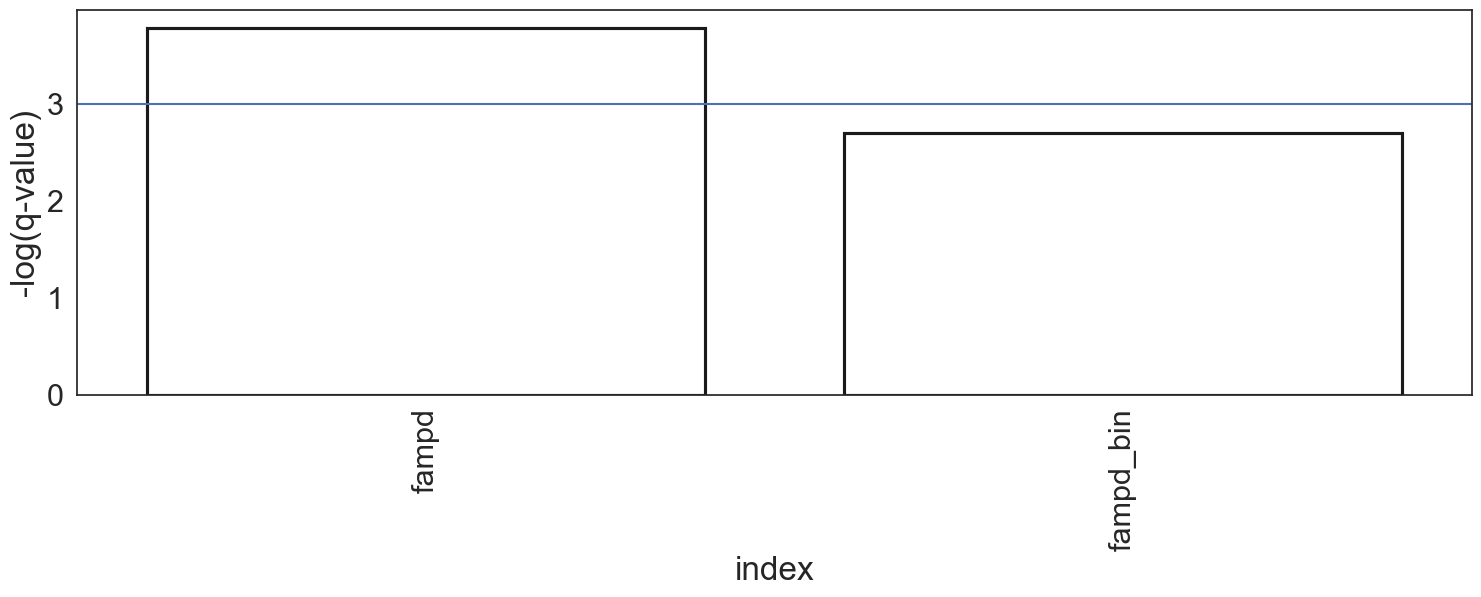

/var/folders/yn/qvpxfrdd5870gxhq9hf9jvc40000gq/T/ipykernel_17897/2629150738.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


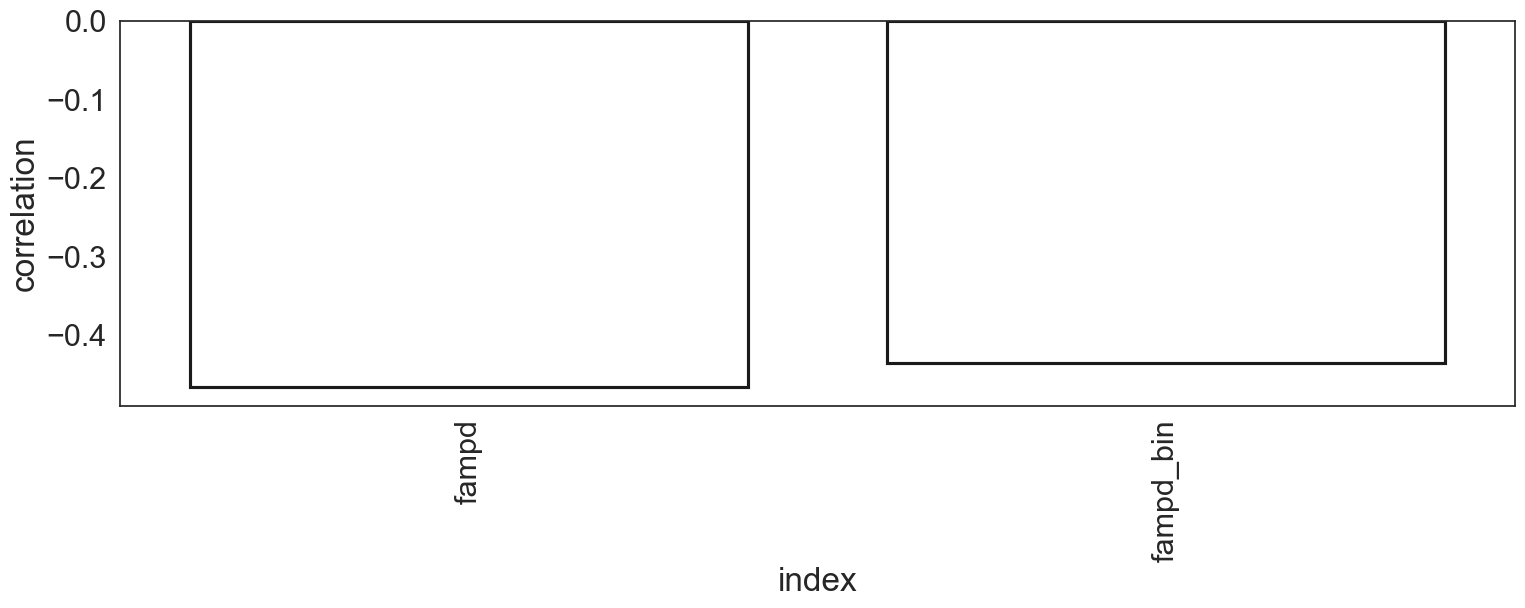

In [56]:
from statsmodels.stats.multitest import multipletests 

def getpvalue(x, y):
    # print(x.shape)
    _, pval = pearsonr(x,y)
    return pval

cols = dico_feat[dico_feat.Category !="ID"].Variable.unique().tolist()
cols = [it for it in cols if it in df_res.columns.tolist()]
toremove = ['APOE', "NSD_STAGE", "Stage_G", "clockdraw", 
            "lexical", "MODBNT", "OTHNEURO", "TMT_A", "TMT_B",
            "howlive", "sex_orient", "updrs4_score"]

cols = [it for it in cols if it not in toremove]
group = "GBA1"
mat = df_res[df_res.group==group][["Model error"]+cols].corr(method=getmeth)
mat = mat.iloc[0, 1:].reset_index()
mat.columns = ["index", "correlation"]
pval = df_res[df_res.group==group][["Model error"]+cols].corr(method=getpvalue)
pval = pval.iloc[0, 1:].reset_index()
pval.columns = ["index", "pval"]
mat = mat.merge(pval, on="index")
_, qval, _, _ = multipletests(mat["pval"].values, method="holm")
mat["qval"] = qval

mat["-log(q-value)"] = -np.log(mat["qval"])
mat

mat = mat.sort_values("-log(q-value)", ascending=False)
sns.set(style="white", font_scale=2)
fig, ax = plt.subplots(figsize=(18,5))
sns.barplot(data=mat[mat.qval<1], x="index", y="-log(q-value)", ax=ax, color="k", fill=False)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
ax.axhline(y=-np.log(0.05))
plt.show()
fig, ax = plt.subplots(figsize=(18,5))
sns.barplot(data=mat[mat.qval<1], x="index", y="correlation", ax=ax, color="k", fill=False)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
plt.show()